# Test 13: Sparsity + Квантование — реальное сжатие

**Вопрос:** Какой реальный коэффициент сжатия даёт chaos SAE + top-k + квантование латентов?

**План:**
- Обучить V4 Chaos (a=1) и TopK+ReLU на MNIST
- После top-k: хранить только K ненулевых значений + их индексы
- Квантовать значения до 2, 4, 8 бит
- Измерить: коэффициент сжатия, loss после деквантования, качество реконструкции
- Сравнить chaos vs ReLU при одинаковом сжатии

**Метрики:** compression ratio, MSE после квантования, dead neurons, PSNR

**Данные:** MNIST, N=5 прогонов

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Базовые компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def make_chaos_activation(a=1.0, w=0.5, b=4.0):
    @tf.function
    def activation(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    return activation


def build_chaos_ae(image_size=(28, 28), latent_dim=128, k_active=32, a=1.0):
    act = make_chaos_activation(a=a)
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(act)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_topk_relu(image_size=(28, 28), latent_dim=128, k_active=32):
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print("Core components ready.")

Core components ready.


In [3]:
# === Функции квантования ===

def quantize_latents(latents, bits, k=32):
    """
    Квантует sparse латенты:
    1. Находит K ненулевых значений и их индексы
    2. Квантует значения до заданного количества бит
    3. Возвращает деквантованный полный вектор
    """
    batch_size, latent_dim = latents.shape
    quantized_latents = np.zeros_like(latents)
    
    total_bits_per_sample = 0
    
    for i in range(batch_size):
        vec = latents[i]
        # Находим top-k по абсолютному значению
        top_indices = np.argsort(np.abs(vec))[-k:]
        top_values = vec[top_indices]
        
        if len(top_values) == 0 or np.max(np.abs(top_values)) == 0:
            continue
        
        # Квантование: min-max в диапазон [0, 2^bits - 1]
        v_min = np.min(top_values)
        v_max = np.max(top_values)
        
        if v_max - v_min < 1e-10:
            quantized_latents[i, top_indices] = top_values
            continue
        
        levels = 2 ** bits - 1
        normalized = (top_values - v_min) / (v_max - v_min)
        quantized = np.round(normalized * levels) / levels
        dequantized = quantized * (v_max - v_min) + v_min
        
        quantized_latents[i, top_indices] = dequantized
    
    return quantized_latents


def compute_compression_ratio(latent_dim, k, value_bits, original_bits=32):
    """
    Вычисляет коэффициент сжатия.
    Оригинал: latent_dim * 32 бит (float32)
    Сжато: K значений * value_bits + K индексов * log2(latent_dim) + 2 * 32 (min/max)
    """
    original_size = latent_dim * original_bits
    index_bits = int(np.ceil(np.log2(latent_dim)))
    compressed_size = k * value_bits + k * index_bits + 2 * original_bits  # min, max для деквантования
    return original_size / compressed_size


def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)


print("Quantization functions ready.")

Quantization functions ready.


In [4]:
# === Данные ===
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(f"MNIST train: {x_train.shape}, test: {x_test.shape}")

MNIST train: (60000, 28, 28, 1), test: (10000, 28, 28, 1)


In [5]:
# === Эксперимент ===
NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 128
LATENT_DIM = 128
K_ACTIVE = 32
BIT_LEVELS = [2, 4, 8, 16, 32]  # 32 = без квантования

architectures = {
    'Chaos_a1': lambda: build_chaos_ae(latent_dim=LATENT_DIM, k_active=K_ACTIVE, a=1.0),
    'Chaos_a8': lambda: build_chaos_ae(latent_dim=LATENT_DIM, k_active=K_ACTIVE, a=8.0),
    'TopK_ReLU': lambda: build_topk_relu(latent_dim=LATENT_DIM, k_active=K_ACTIVE),
}

results = {}

for arch_name, builder in architectures.items():
    print(f"\n{'='*60}")
    print(f"  {arch_name}")
    print(f"{'='*60}")
    
    arch_results = []
    
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)
        
        ae, enc = builder()
        ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        
        # Получаем латенты и базовую реконструкцию
        latents = enc.predict(x_test, verbose=0)
        base_recon = ae.predict(x_test, verbose=0)
        base_mse = np.mean((x_test - base_recon) ** 2)
        base_psnr = psnr(x_test, base_recon)
        
        # Dead neurons
        dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
        
        run_results = {
            'base_mse': float(base_mse),
            'base_psnr': float(base_psnr),
            'dead_neurons': dead,
            'quantization': {}
        }
        
        # Получаем декодер (слои после encoder)
        decoder_input = keras.Input(shape=(LATENT_DIM,))
        x = decoder_input
        # Находим слои декодера в autoencoder
        found_latent = False
        for layer in ae.layers:
            if layer.name == 'latent_ksparse':
                found_latent = True
                continue
            if found_latent:
                x = layer(x)
        decoder = keras.Model(decoder_input, x)
        
        for bits in BIT_LEVELS:
            if bits == 32:
                q_latents = latents  # без квантования
            else:
                q_latents = quantize_latents(latents, bits, k=K_ACTIVE)
            
            # Реконструкция из квантованных латентов
            q_recon = decoder.predict(q_latents, verbose=0)
            q_mse = float(np.mean((x_test - q_recon) ** 2))
            q_psnr = float(psnr(x_test, q_recon))
            
            # Сжатие
            cr = compute_compression_ratio(LATENT_DIM, K_ACTIVE, bits)
            
            run_results['quantization'][bits] = {
                'mse': q_mse,
                'psnr': q_psnr,
                'compression_ratio': float(cr),
            }
        
        arch_results.append(run_results)
        
        print(f"  run {run+1}/{NUM_RUNS}: base_mse={base_mse:.4f}, dead={dead}")
        for bits in BIT_LEVELS:
            q = run_results['quantization'][bits]
            print(f"    {bits:2d} bit: mse={q['mse']:.4f}, psnr={q['psnr']:.1f}dB, "
                  f"compression={q['compression_ratio']:.1f}x")
        
        del ae, enc, decoder
        keras.backend.clear_session()
    
    results[arch_name] = arch_results

print("\nAll experiments done.")


  Chaos_a1


2026-04-06 17:37:31.330766: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-06 17:37:31.330790: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-06 17:37:31.330792: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-06 17:37:31.330806: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 17:37:31.330814: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-06 17:37:31.844238: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  run 1/5: base_mse=0.0093, dead=1
     2 bit: mse=0.0105, psnr=19.8dB, compression=11.6x
     4 bit: mse=0.0093, psnr=20.3dB, compression=9.8x
     8 bit: mse=0.0093, psnr=20.3dB, compression=7.5x
    16 bit: mse=0.0093, psnr=20.3dB, compression=5.1x
    32 bit: mse=0.0093, psnr=20.3dB, compression=3.1x
  run 2/5: base_mse=0.0093, dead=0
     2 bit: mse=0.0105, psnr=19.8dB, compression=11.6x
     4 bit: mse=0.0094, psnr=20.3dB, compression=9.8x
     8 bit: mse=0.0093, psnr=20.3dB, compression=7.5x
    16 bit: mse=0.0093, psnr=20.3dB, compression=5.1x
    32 bit: mse=0.0093, psnr=20.3dB, compression=3.1x
  run 3/5: base_mse=0.0094, dead=0
     2 bit: mse=0.0107, psnr=19.7dB, compression=11.6x
     4 bit: mse=0.0095, psnr=20.2dB, compression=9.8x
     8 bit: mse=0.0094, psnr=20.3dB, compression=7.5x
    16 bit: mse=0.0094, psnr=20.3dB, compression=5.1x
    32 bit: mse=0.0094, psnr=20.3dB, compression=3.1x
  run 4/5: base_mse=0.0093, dead=0
     2 bit: mse=0.0105, psnr=19.8dB, compressio

In [6]:
# === Сводная таблица ===
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА: КАЧЕСТВО vs СЖАТИЕ")
print("=" * 80)
print(f"{'Архитектура':<15} {'Биты':>5} {'MSE':>10} {'PSNR':>8} {'Сжатие':>8} {'Dead':>6}")
print('-' * 80)

summary = {}

for arch_name in architectures:
    runs = results[arch_name]
    dead_mean = np.mean([r['dead_neurons'] for r in runs])
    
    summary[arch_name] = {}
    
    for bits in BIT_LEVELS:
        mses = [r['quantization'][bits]['mse'] for r in runs]
        psnrs = [r['quantization'][bits]['psnr'] for r in runs]
        cr = runs[0]['quantization'][bits]['compression_ratio']
        
        summary[arch_name][bits] = {
            'mse_mean': np.mean(mses), 'mse_std': np.std(mses),
            'psnr_mean': np.mean(psnrs), 'psnr_std': np.std(psnrs),
            'cr': cr,
        }
        
        print(f"{arch_name:<15} {bits:>5} "
              f"{np.mean(mses):>9.4f} "
              f"{np.mean(psnrs):>7.1f}dB "
              f"{cr:>7.1f}x "
              f"{dead_mean:>5.1f}")
    print()


СВОДНАЯ ТАБЛИЦА: КАЧЕСТВО vs СЖАТИЕ
Архитектура      Биты        MSE     PSNR   Сжатие   Dead
--------------------------------------------------------------------------------
Chaos_a1            2    0.0105    19.8dB    11.6x   0.2
Chaos_a1            4    0.0093    20.3dB     9.8x   0.2
Chaos_a1            8    0.0093    20.3dB     7.5x   0.2
Chaos_a1           16    0.0093    20.3dB     5.1x   0.2
Chaos_a1           32    0.0093    20.3dB     3.1x   0.2

Chaos_a8            2    0.0671    11.7dB    11.6x   0.0
Chaos_a8            4    0.0670    11.7dB     9.8x   0.0
Chaos_a8            8    0.0670    11.7dB     7.5x   0.0
Chaos_a8           16    0.0670    11.7dB     5.1x   0.0
Chaos_a8           32    0.0670    11.7dB     3.1x   0.0

TopK_ReLU           2    0.0204    16.9dB    11.6x  61.4
TopK_ReLU           4    0.0119    19.2dB     9.8x  61.4
TopK_ReLU           8    0.0115    19.4dB     7.5x  61.4
TopK_ReLU          16    0.0115    19.4dB     5.1x  61.4
TopK_ReLU          32   

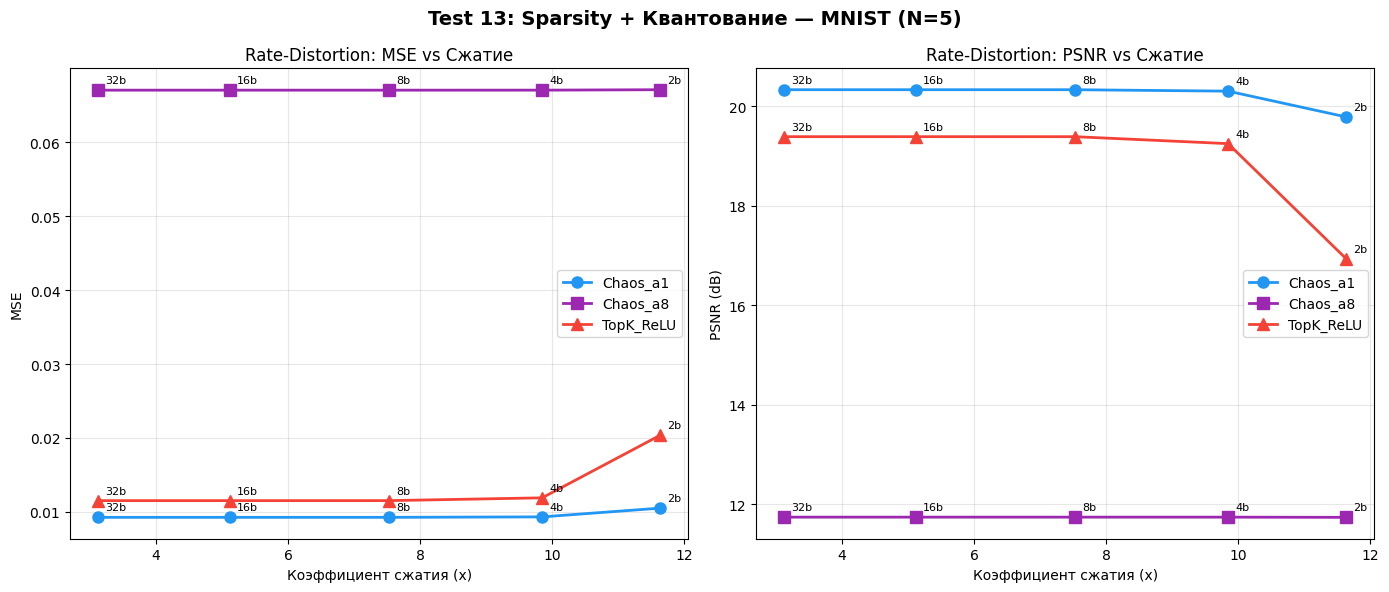

In [7]:
# === Rate-Distortion кривые ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Chaos_a1': '#2196F3', 'Chaos_a8': '#9C27B0', 'TopK_ReLU': '#F44336'}
markers = {'Chaos_a1': 'o', 'Chaos_a8': 's', 'TopK_ReLU': '^'}

for arch_name in architectures:
    crs = [summary[arch_name][b]['cr'] for b in BIT_LEVELS]
    mses = [summary[arch_name][b]['mse_mean'] for b in BIT_LEVELS]
    psnrs = [summary[arch_name][b]['psnr_mean'] for b in BIT_LEVELS]
    
    axes[0].plot(crs, mses, color=colors[arch_name], marker=markers[arch_name],
                linewidth=2, markersize=8, label=arch_name)
    for i, bits in enumerate(BIT_LEVELS):
        axes[0].annotate(f'{bits}b', (crs[i], mses[i]), textcoords="offset points",
                        xytext=(5, 5), fontsize=8)
    
    axes[1].plot(crs, psnrs, color=colors[arch_name], marker=markers[arch_name],
                linewidth=2, markersize=8, label=arch_name)
    for i, bits in enumerate(BIT_LEVELS):
        axes[1].annotate(f'{bits}b', (crs[i], psnrs[i]), textcoords="offset points",
                        xytext=(5, 5), fontsize=8)

axes[0].set_xlabel('Коэффициент сжатия (x)')
axes[0].set_ylabel('MSE')
axes[0].set_title('Rate-Distortion: MSE vs Сжатие')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Коэффициент сжатия (x)')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Rate-Distortion: PSNR vs Сжатие')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Test 13: Sparsity + Квантование — MNIST (N={NUM_RUNS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Обучение модели для визуализации...


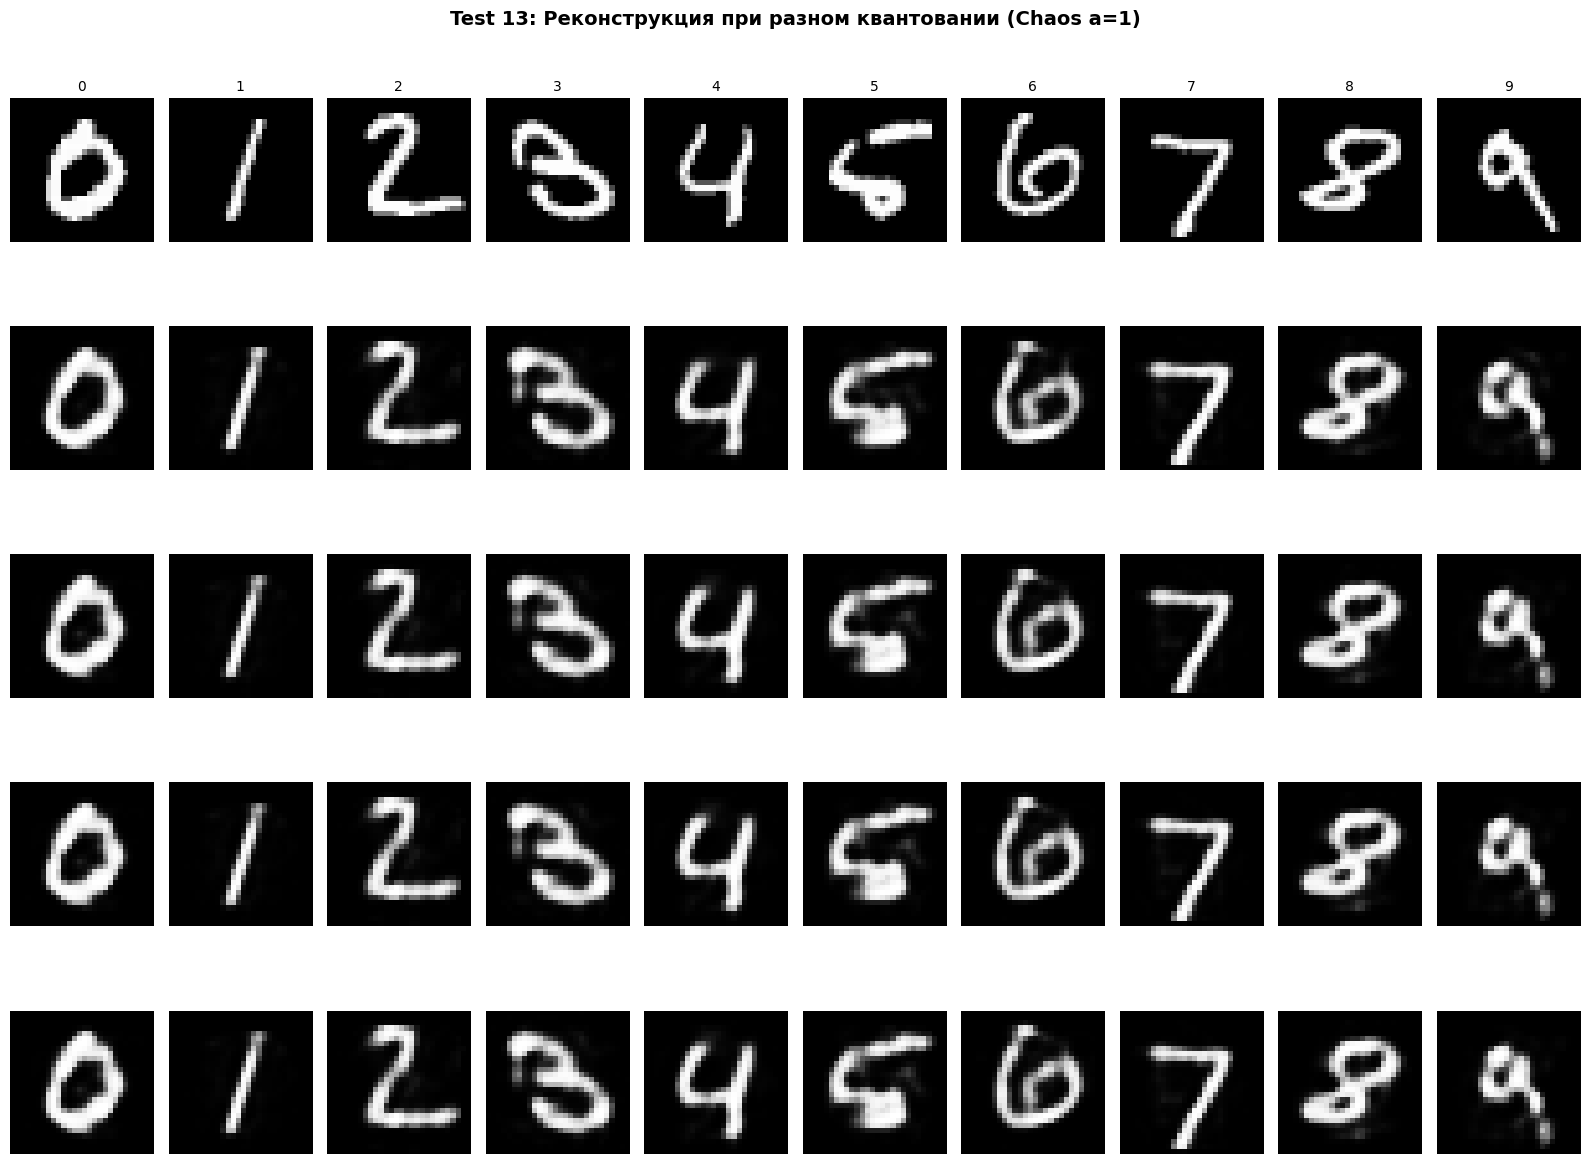

Done.


In [8]:
# === Визуализация реконструкций при разном квантовании ===
print("Обучение модели для визуализации...")
np.random.seed(0)
tf.random.set_seed(0)
ae_viz, enc_viz = build_chaos_ae(latent_dim=LATENT_DIM, k_active=K_ACTIVE, a=1.0)
ae_viz.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

# Декодер
latents_viz = enc_viz.predict(x_test, verbose=0)
decoder_input = keras.Input(shape=(LATENT_DIM,))
x = decoder_input
found_latent = False
for layer in ae_viz.layers:
    if layer.name == 'latent_ksparse':
        found_latent = True
        continue
    if found_latent:
        x = layer(x)
decoder_viz = keras.Model(decoder_input, x)

# Выбираем цифры 0-9
sample_indices = [np.where(y_test == d)[0][0] for d in range(10)]
samples = x_test[sample_indices]
sample_latents = latents_viz[sample_indices]

viz_bits = [2, 4, 8, 32]
fig, axes = plt.subplots(len(viz_bits) + 1, 10, figsize=(16, 2.5 * (len(viz_bits) + 1)))

# Оригиналы
for i in range(10):
    axes[0, i].imshow(samples[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(str(i), fontsize=10)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9, rotation=0, labelpad=60)

# Реконструкции при разном квантовании
for row, bits in enumerate(viz_bits, 1):
    if bits == 32:
        q_lat = sample_latents
        label = 'No quant'
    else:
        q_lat = quantize_latents(sample_latents, bits, k=K_ACTIVE)
        label = f'{bits}-bit'
    
    recons = decoder_viz.predict(q_lat, verbose=0)
    cr = compute_compression_ratio(LATENT_DIM, K_ACTIVE, bits)
    
    for i in range(10):
        axes[row, i].imshow(recons[i, :, :, 0], cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'{label}\n{cr:.1f}x', fontsize=9, rotation=0, labelpad=60)

plt.suptitle('Test 13: Реконструкция при разном квантовании (Chaos a=1)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

del ae_viz, enc_viz, decoder_viz
keras.backend.clear_session()
print("Done.")

In [9]:
# === Сохранение результатов ===
save_data = {
    'experiment': 'quantization_compression',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'dataset': 'MNIST',
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
        'bit_levels': BIT_LEVELS,
    },
    'results': results,
}

json_path = f'../jsons/quantization_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/quantization_20260406_175651.json
